# SIDRA (IBGE) - Indicadores Econômicos

Visualização dos principais indicadores macroeconômicos coletados do sistema SIDRA/IBGE.

- **Dados mensais**: últimos 5 anos (a partir de março/2021)
- **Dados trimestrais**: últimos 5 anos (a partir de 2021-Q1)
- **Dados anuais**: últimos 20 anos (a partir de 2004)

## Configuração

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Datas de corte
MONTHLY_CUTOFF = '2021-03-01'
QUARTERLY_CUTOFF = '2021-01-01'
ANNUAL_CUTOFF = '2004-01-01'

SOURCE_TEXT = 'Fonte: IBGE / SIDRA'

def add_source(ax, text=SOURCE_TEXT):
    """Adiciona anotação de fonte no canto inferior direito."""
    ax.annotate(text, xy=(1, 0), xycoords='axes fraction',
                fontsize=8, color='gray', ha='right', va='top',
                xytext=(0, -25), textcoords='offset points')

def rotate_labels(ax, rotation=45):
    """Rotaciona rótulos do eixo x."""
    plt.setp(ax.get_xticklabels(), rotation=rotation, ha='right')

print('Configuração completa.')

Setup completo.


## Carregamento dos Dados

In [2]:
monthly = pd.read_csv('../data/sidra/monthly.csv', index_col=0, parse_dates=True)
quarterly = pd.read_csv('../data/sidra/quarterly.csv', index_col=0, parse_dates=True)
annual = pd.read_csv('../data/sidra/annual.csv', index_col=0, parse_dates=True)

# Aplicar filtros de data
m = monthly[monthly.index >= MONTHLY_CUTOFF].copy()
q = quarterly[quarterly.index >= QUARTERLY_CUTOFF].copy()
a = annual[annual.index >= ANNUAL_CUTOFF].copy()

print(f"Monthly: {m.shape[0]} rows, {m.shape[1]} columns ({m.index.min().strftime('%Y-%m')} a {m.index.max().strftime('%Y-%m')})")
print(f"Quarterly: {q.shape[0]} rows, {q.shape[1]} columns ({q.index.min().strftime('%Y-%m')} a {q.index.max().strftime('%Y-%m')})")
print(f"Annual: {a.shape[0]} rows, {a.shape[1]} columns ({a.index.min().strftime('%Y')} a {a.index.max().strftime('%Y')})")

Monthly: 60 rows, 125 columns (2021-03 a 2026-02)
Quarterly: 20 rows, 45 columns (2021-01 a 2025-10)
Annual: 17 rows, 29 columns (2007 a 2023)


## IPCA - Índice Nacional de Preços ao Consumidor Amplo

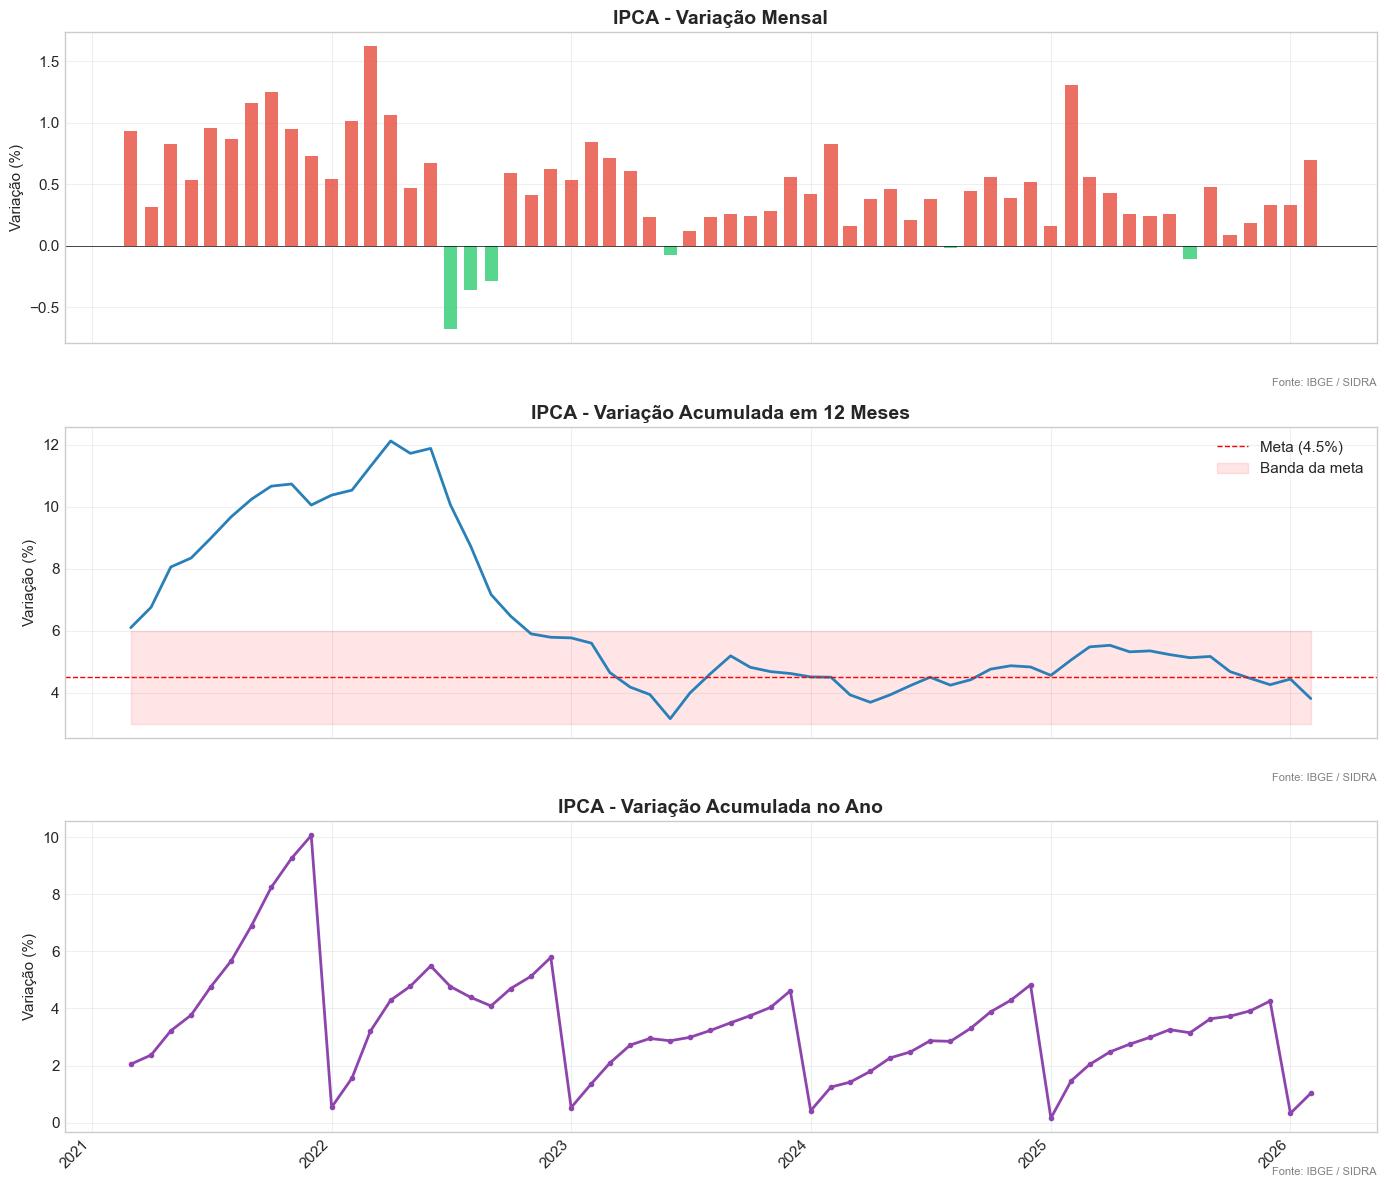

In [3]:
col_mensal = 'ipca__IPCA - Variação mensal - Índice geral'
col_12m = 'ipca__IPCA - Variação acumulada em 12 meses - Índice geral'
col_ano = 'ipca__IPCA - Variação acumulada no ano - Índice geral'

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Variação mensal
ax = axes[0]
data = m[col_mensal].dropna()
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in data.values]
ax.bar(data.index, data.values, width=20, color=colors, alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('IPCA - Variação Mensal', fontsize=14, fontweight='bold')
ax.set_ylabel('Variação (%)')
ax.grid(True, alpha=0.3)
add_source(ax)

# Acumulado 12 meses
ax = axes[1]
data = m[col_12m].dropna()
ax.plot(data.index, data.values, color='#2980b9', linewidth=2)
ax.axhline(y=4.5, color='red', linestyle='--', linewidth=1, label='Meta (4.5%)')
ax.fill_between(data.index, 3.0, 6.0, alpha=0.1, color='red', label='Banda da meta')
ax.set_title('IPCA - Variação Acumulada em 12 Meses', fontsize=14, fontweight='bold')
ax.set_ylabel('Variação (%)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
add_source(ax)

# Acumulado no ano
ax = axes[2]
data = m[col_ano].dropna()
ax.plot(data.index, data.values, color='#8e44ad', linewidth=2, marker='o', markersize=3)
ax.set_title('IPCA - Variação Acumulada no Ano', fontsize=14, fontweight='bold')
ax.set_ylabel('Variação (%)')
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## IPCA por Grupos

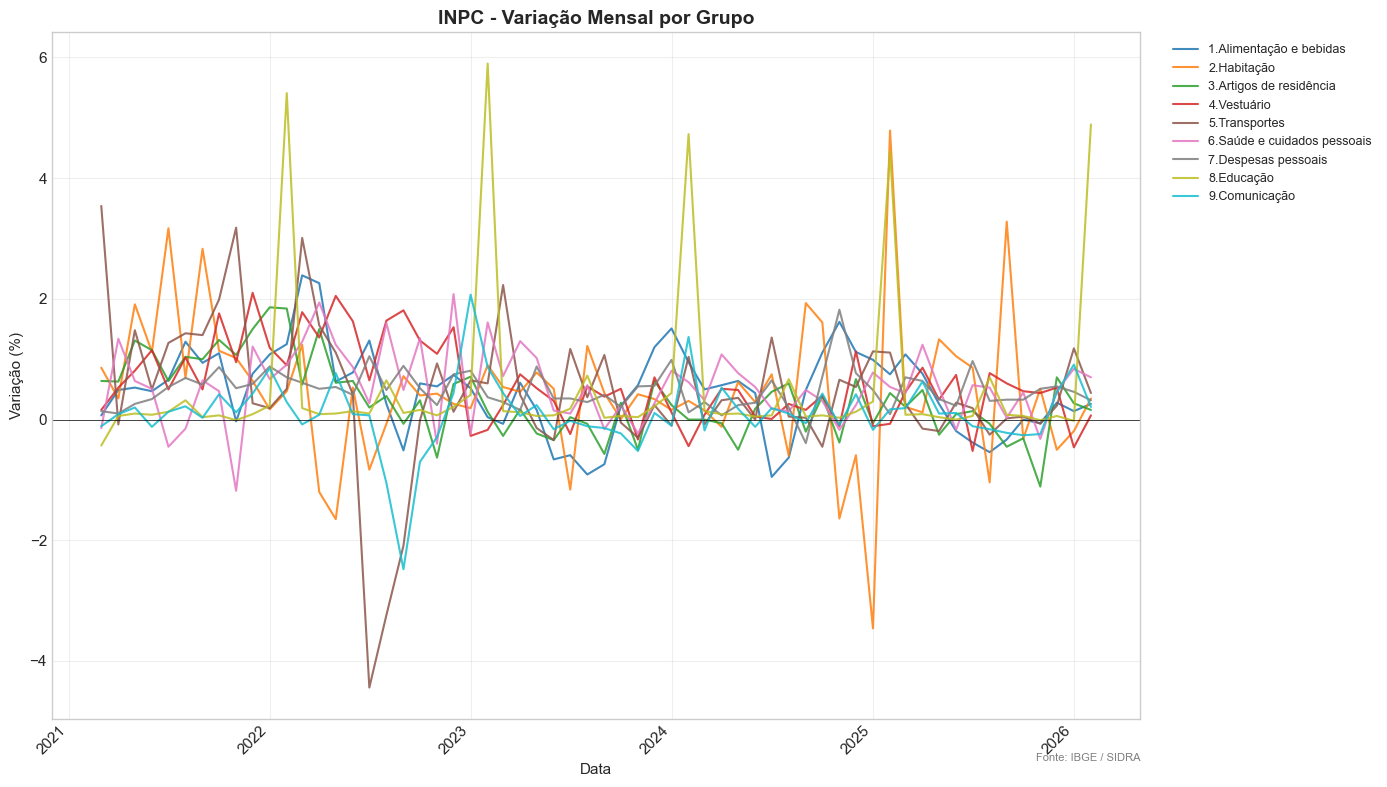

In [4]:
grupo_cols = [c for c in m.columns if c.startswith('ipca_grupos__INPC - Variação mensal') and 'Índice geral' not in c]

fig, ax = plt.subplots(figsize=(14, 8))

cmap = plt.cm.get_cmap('tab10', len(grupo_cols))
for i, col in enumerate(grupo_cols):
    label = col.split(' - ')[-1]
    data = m[col].dropna()
    ax.plot(data.index, data.values, linewidth=1.5, label=label, color=cmap(i), alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('INPC - Variação Mensal por Grupo', fontsize=14, fontweight='bold')
ax.set_ylabel('Variação (%)')
ax.set_xlabel('Data')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## IPP - Índice de Preços ao Produtor

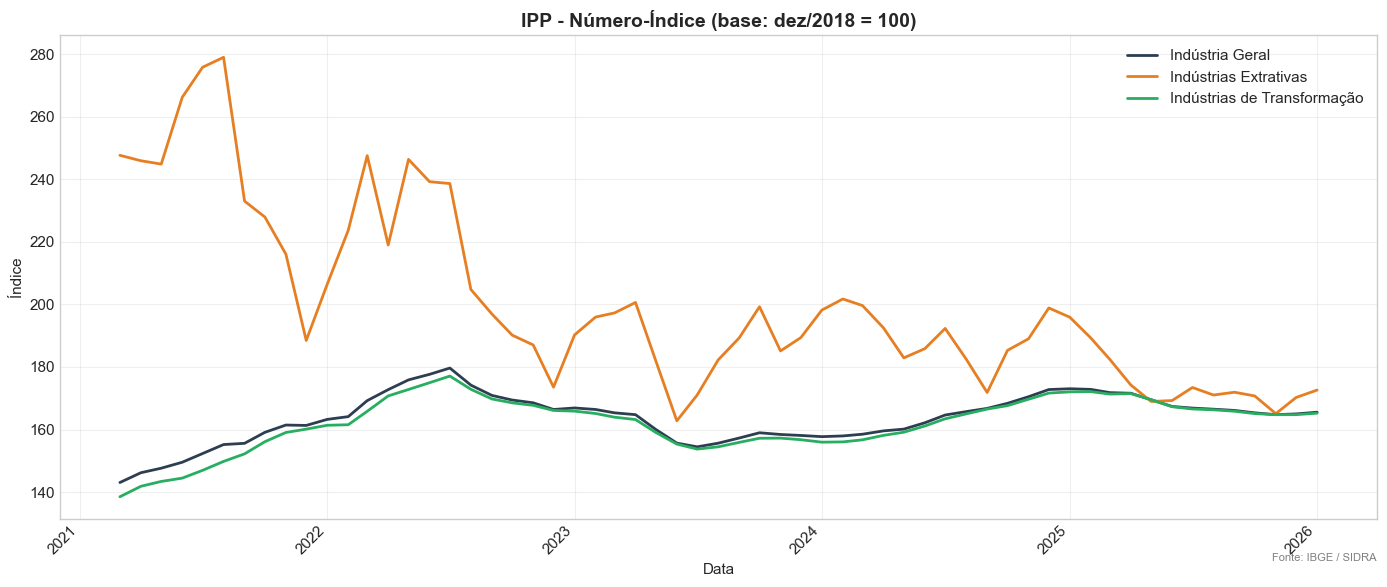

In [5]:
col_geral = 'ipp__IPP - Número-índice (dezembro de 2018 = 100) - Indústria Geral'
col_extr = 'ipp__IPP - Número-índice (dezembro de 2018 = 100) - B Indústrias Extrativas'
col_transf = 'ipp__IPP - Número-índice (dezembro de 2018 = 100) - C Indústrias de Transformação'

fig, ax = plt.subplots(figsize=(14, 6))

for col, label, color in [(col_geral, 'Indústria Geral', '#2c3e50'),
                           (col_extr, 'Indústrias Extrativas', '#e67e22'),
                           (col_transf, 'Indústrias de Transformação', '#27ae60')]:
    data = m[col].dropna()
    ax.plot(data.index, data.values, linewidth=2, label=label, color=color)

ax.set_title('IPP - Número-Índice (base: dez/2018 = 100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Índice')
ax.set_xlabel('Data')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## SINAPI - Custo Médio por m²

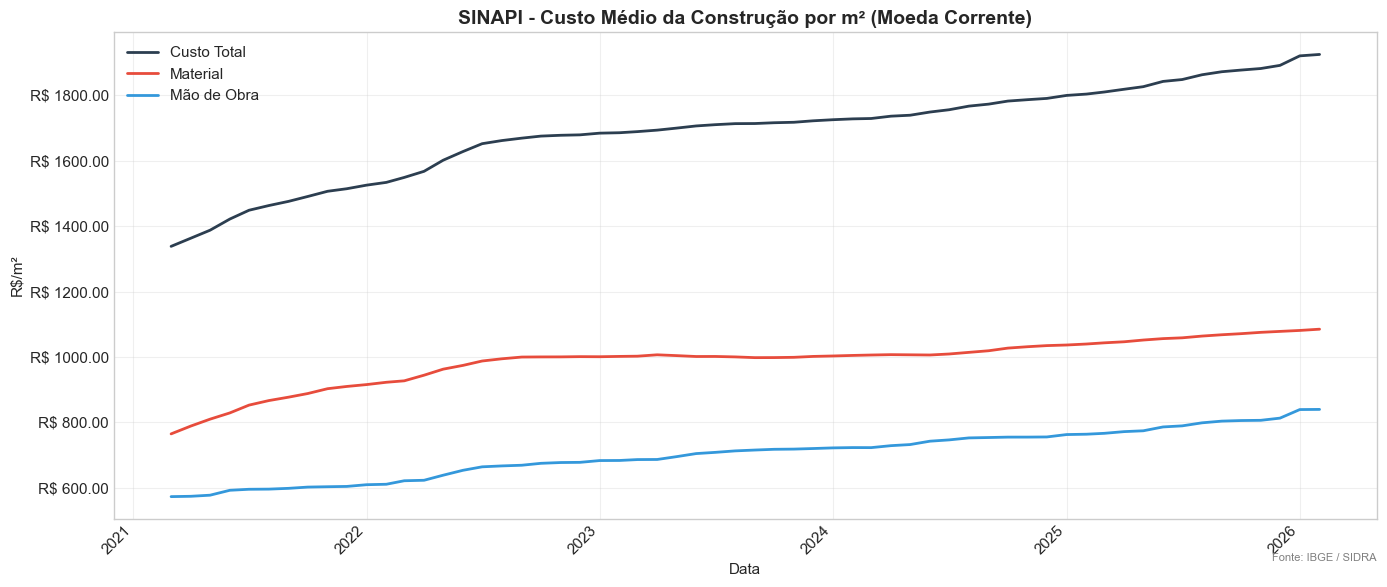

In [6]:
col_total = 'sinapi__Custo médio m² - moeda corrente'
col_mat = 'sinapi__Custo médio m² - componente material - moeda corrente'
col_mo = 'sinapi__Custo médio m² - componente mão-de-obra - moeda corrente'

fig, ax = plt.subplots(figsize=(14, 6))

for col, label, color in [(col_total, 'Custo Total', '#2c3e50'),
                           (col_mat, 'Material', '#e74c3c'),
                           (col_mo, 'Mão de Obra', '#3498db')]:
    data = m[col].dropna()
    ax.plot(data.index, data.values, linewidth=2, label=label, color=color)

ax.set_title('SINAPI - Custo Médio da Construção por m² (Moeda Corrente)', fontsize=14, fontweight='bold')
ax.set_ylabel('R$/m²')
ax.set_xlabel('Data')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.2f'))
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## Taxa de Desocupação

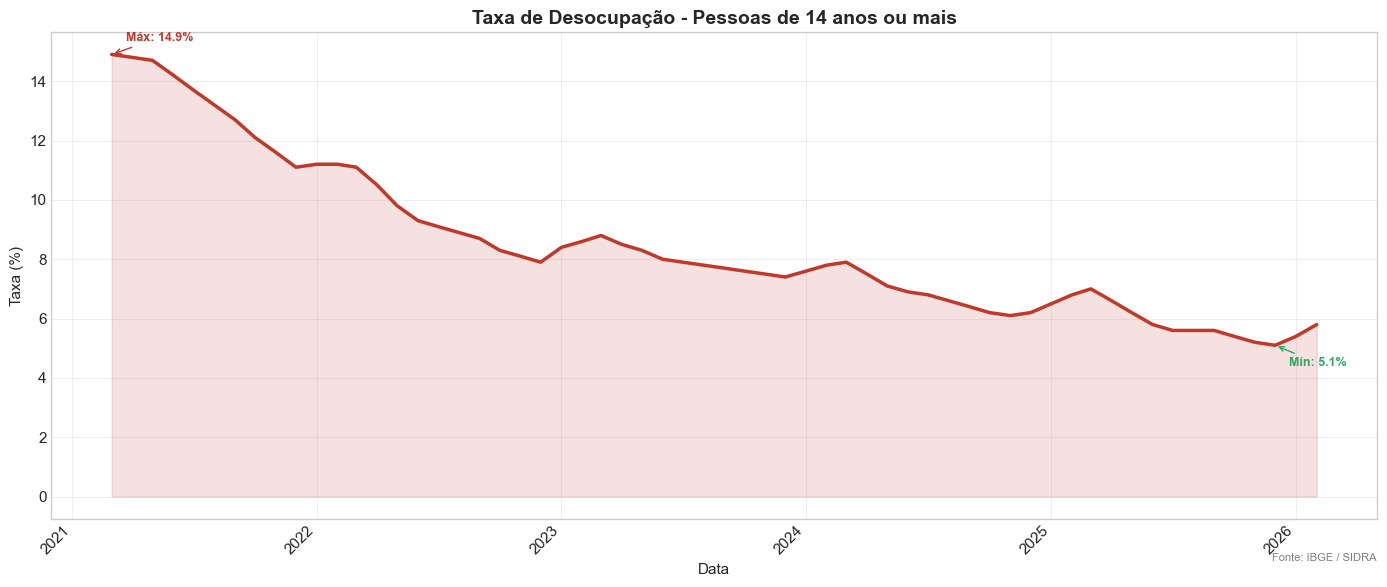

In [7]:
col_desoc = [c for c in m.columns if c.startswith('desocupacao__')][0]

fig, ax = plt.subplots(figsize=(14, 6))

data = m[col_desoc].dropna()
ax.plot(data.index, data.values, color='#c0392b', linewidth=2.5)
ax.fill_between(data.index, data.values, alpha=0.15, color='#c0392b')

ax.set_title('Taxa de Desocupação - Pessoas de 14 anos ou mais', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa (%)')
ax.set_xlabel('Data')
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

# Anotar mínimo e máximo
if len(data) > 0:
    idx_max = data.idxmax()
    idx_min = data.idxmin()
    ax.annotate(f'Máx: {data[idx_max]:.1f}%', xy=(idx_max, data[idx_max]),
                fontsize=9, color='#c0392b', fontweight='bold',
                xytext=(10, 10), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='#c0392b'))
    ax.annotate(f'Mín: {data[idx_min]:.1f}%', xy=(idx_min, data[idx_min]),
                fontsize=9, color='#27ae60', fontweight='bold',
                xytext=(10, -15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='#27ae60'))

plt.tight_layout()
plt.show()

## Rendimento Médio - Nominal e Real

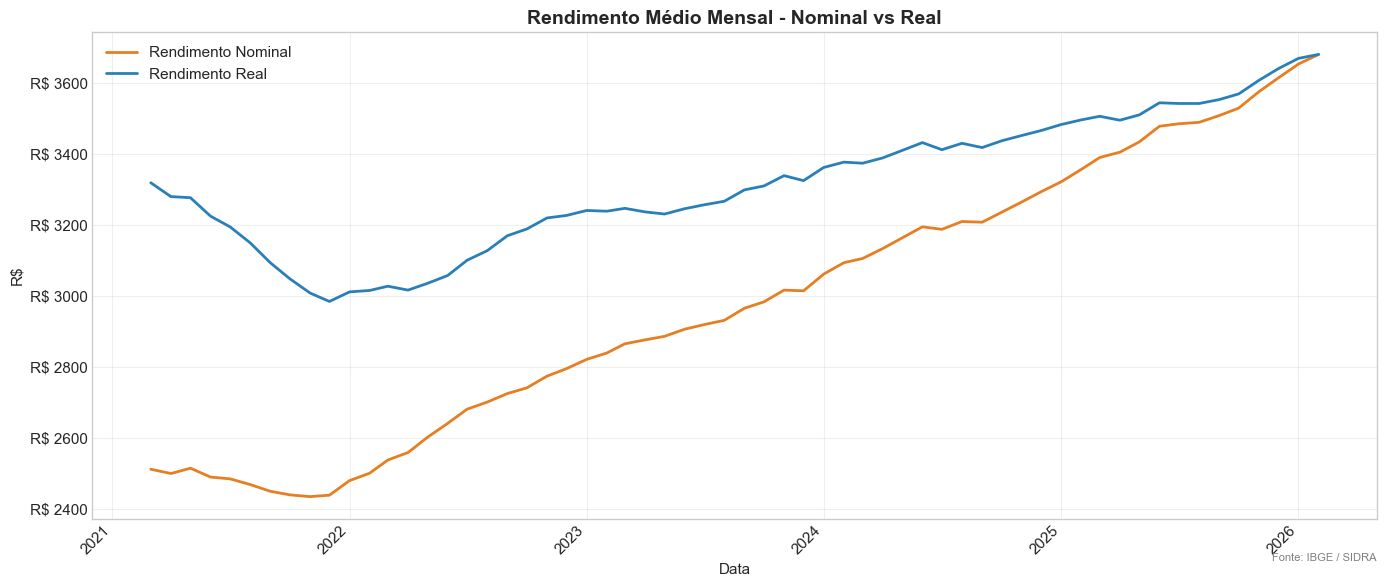

In [8]:
rend_cols = [c for c in m.columns if c.startswith('rendimento_medio__')]
col_nominal = [c for c in rend_cols if 'nominal' in c.lower()][0]
col_real = [c for c in rend_cols if 'real' in c.lower()][0]

fig, ax = plt.subplots(figsize=(14, 6))

data_nom = m[col_nominal].dropna()
data_real = m[col_real].dropna()

ax.plot(data_nom.index, data_nom.values, color='#e67e22', linewidth=2, label='Rendimento Nominal')
ax.plot(data_real.index, data_real.values, color='#2980b9', linewidth=2, label='Rendimento Real')

ax.set_title('Rendimento Médio Mensal - Nominal vs Real', fontsize=14, fontweight='bold')
ax.set_ylabel('R$')
ax.set_xlabel('Data')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.0f'))
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## Produção Física Industrial (PIMPF)

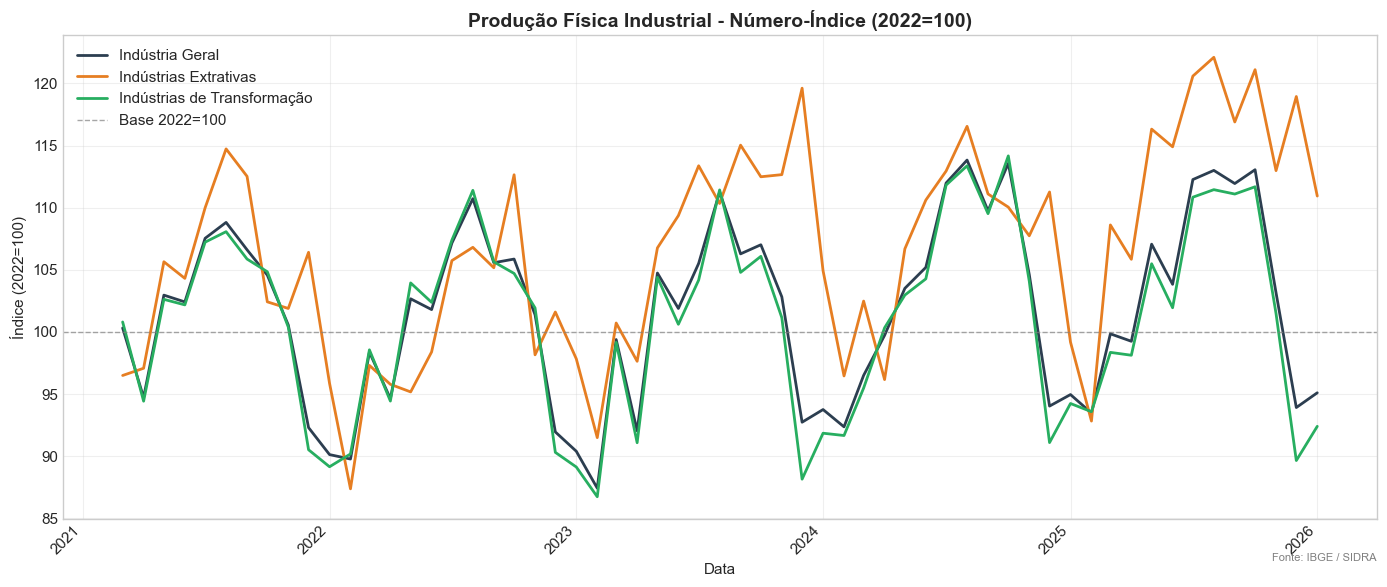

In [9]:
col_pf_geral = 'producao_fisica_industrial__PIMPF - Número-índice (2022=100) - 1 Indústria geral'
col_pf_extr = 'producao_fisica_industrial__PIMPF - Número-índice (2022=100) - 2 Indústrias extrativas'
col_pf_transf = 'producao_fisica_industrial__PIMPF - Número-índice (2022=100) - 3 Indústrias de transformação'

fig, ax = plt.subplots(figsize=(14, 6))

for col, label, color in [(col_pf_geral, 'Indústria Geral', '#2c3e50'),
                           (col_pf_extr, 'Indústrias Extrativas', '#e67e22'),
                           (col_pf_transf, 'Indústrias de Transformação', '#27ae60')]:
    data = m[col].dropna()
    ax.plot(data.index, data.values, linewidth=2, label=label, color=color)

ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Base 2022=100')
ax.set_title('Produção Física Industrial - Número-Índice (2022=100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Índice (2022=100)')
ax.set_xlabel('Data')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## Serviços PMS - Índice de Volume

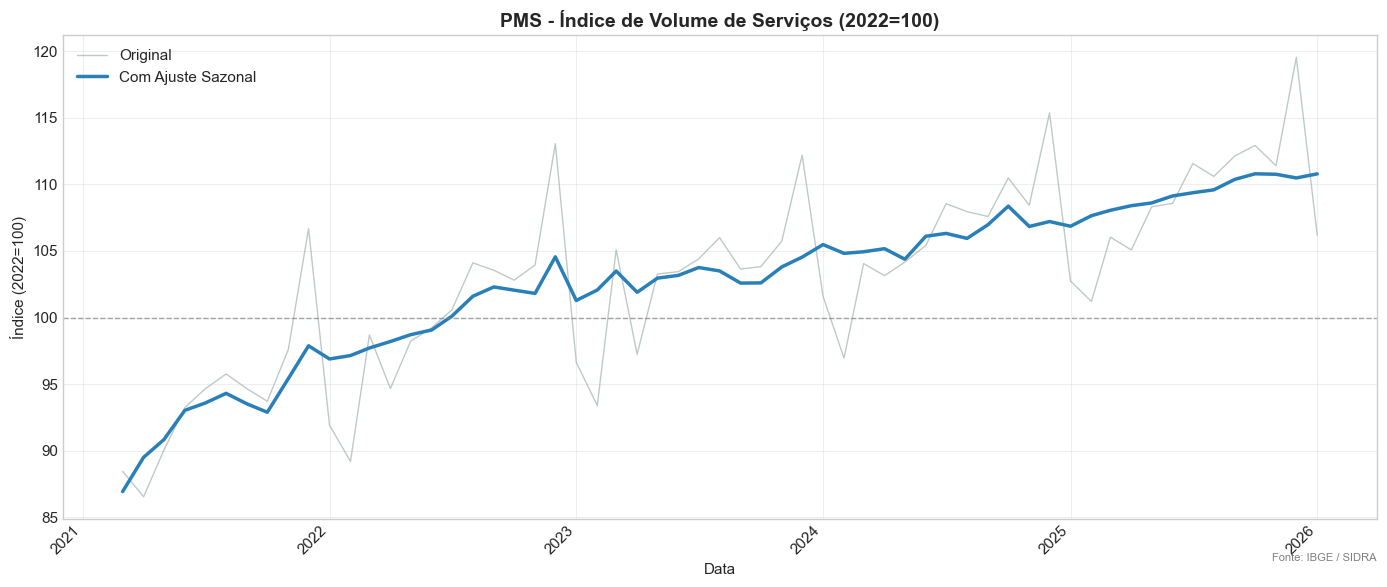

In [10]:
col_pms = 'servicos_pms__PMS - Número-índice (2022=100) - Índice de volume de serviços - Total'
col_pms_sa = 'servicos_pms__PMS - Número-índice com ajuste sazonal (2022=100) - Índice de volume de serviços - Total'

fig, ax = plt.subplots(figsize=(14, 6))

data_pms = m[col_pms].dropna()
data_pms_sa = m[col_pms_sa].dropna()

ax.plot(data_pms.index, data_pms.values, color='#95a5a6', linewidth=1, alpha=0.6, label='Original')
ax.plot(data_pms_sa.index, data_pms_sa.values, color='#2980b9', linewidth=2.5, label='Com Ajuste Sazonal')

ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('PMS - Índice de Volume de Serviços (2022=100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Índice (2022=100)')
ax.set_xlabel('Data')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## PIB Trimestral - Índice de Volume

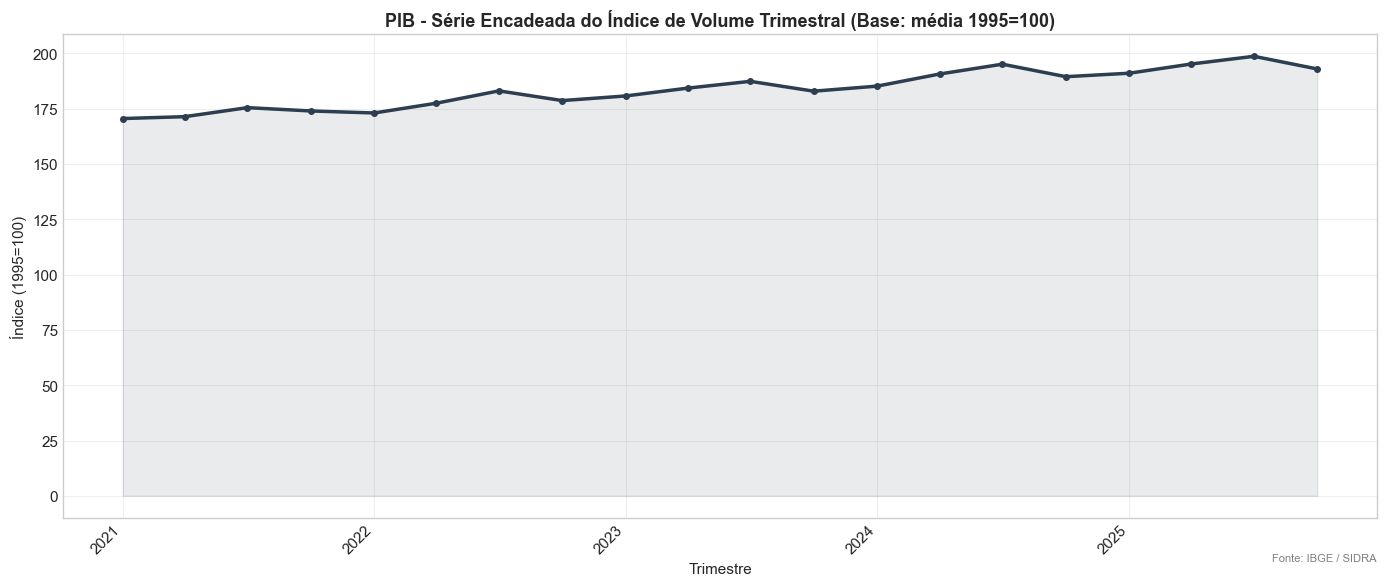

In [11]:
col_pib = [c for c in q.columns if c.startswith('pib__')][0]

fig, ax = plt.subplots(figsize=(14, 6))

data = q[col_pib].dropna()
ax.plot(data.index, data.values, color='#2c3e50', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(data.index, data.values, alpha=0.1, color='#2c3e50')

ax.set_title('PIB - Série Encadeada do Índice de Volume Trimestral (Base: média 1995=100)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Índice (1995=100)')
ax.set_xlabel('Trimestre')
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## PIB Setorial - Variação Trimestral YoY

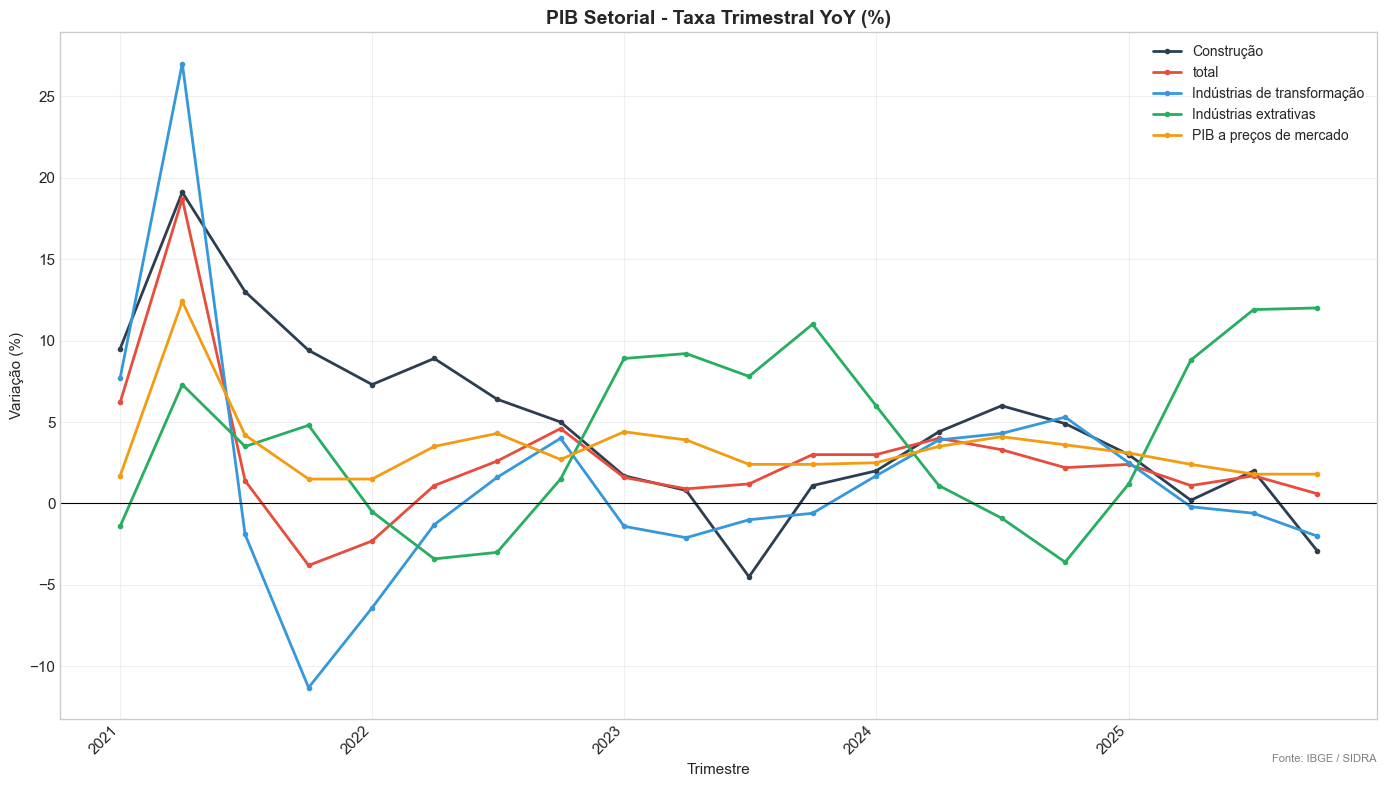

In [12]:
yoy_cols = [c for c in q.columns if 'Taxa trimestral (em relação ao mesmo período do ano anterior)' in c]

fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60', '#f39c12', '#8e44ad']
for i, col in enumerate(yoy_cols):
    label = col.split(' - ')[-1]
    data = q[col].dropna()
    ax.plot(data.index, data.values, linewidth=2, label=label,
            color=colors[i % len(colors)], marker='o', markersize=3)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('PIB Setorial - Taxa Trimestral YoY (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Variação (%)')
ax.set_xlabel('Trimestre')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## PIB Setorial - Valores a Preços Correntes

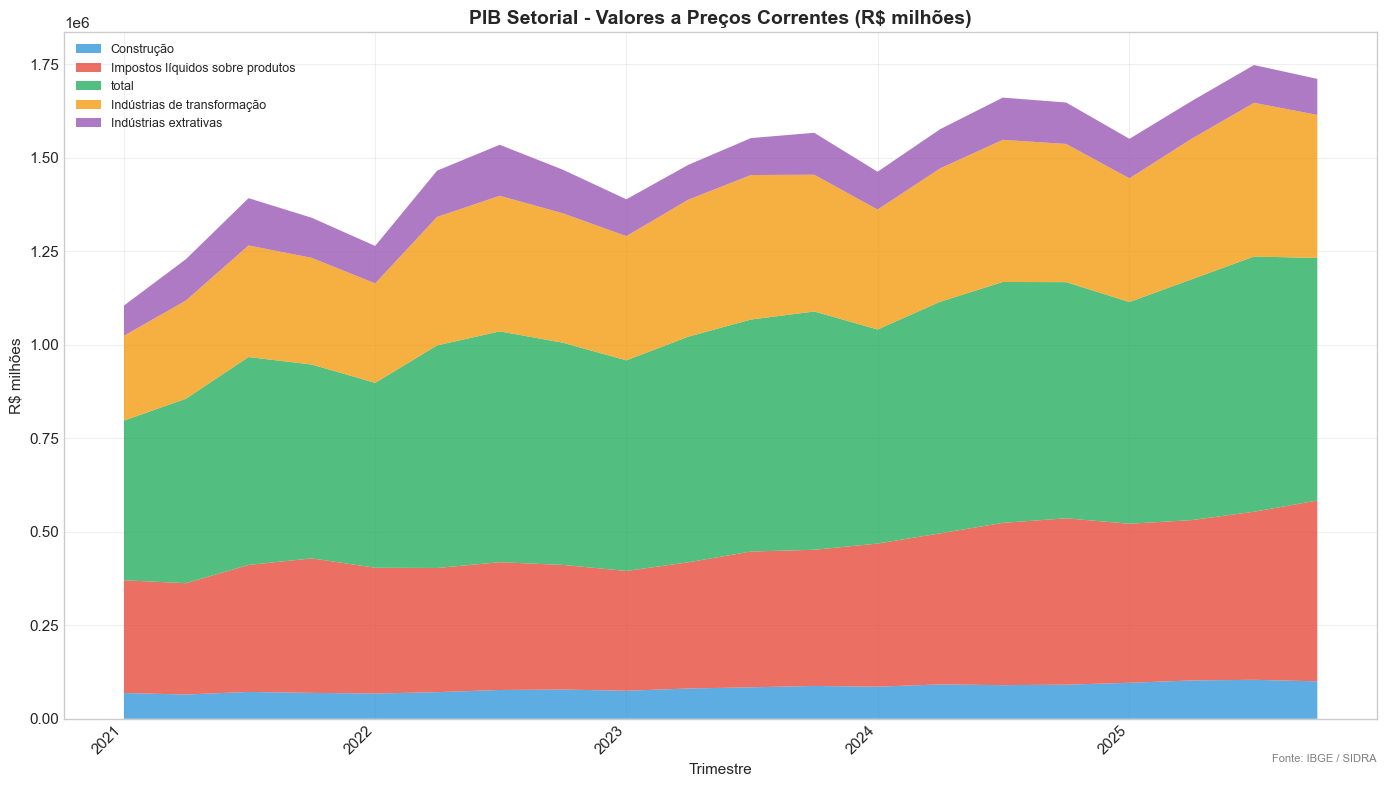

In [13]:
corrente_cols = [c for c in q.columns if 'Valores a preços correntes' in c
                 and 'PIB a preços de mercado' not in c
                 and 'Valor adicionado' not in c]

fig, ax = plt.subplots(figsize=(14, 8))

# Preparar dados para área empilhada
df_stack = q[corrente_cols].dropna(how='all')
labels = [c.split(' - ')[-1] for c in corrente_cols]

# Converter para numérico
df_stack = df_stack.apply(pd.to_numeric, errors='coerce')

colors_stack = ['#3498db', '#e74c3c', '#27ae60', '#f39c12', '#9b59b6']
ax.stackplot(df_stack.index, *[df_stack[c].values for c in corrente_cols],
             labels=labels, colors=colors_stack[:len(corrente_cols)], alpha=0.8)

ax.set_title('PIB Setorial - Valores a Preços Correntes (R$ milhões)', fontsize=14, fontweight='bold')
ax.set_ylabel('R$ milhões')
ax.set_xlabel('Trimestre')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## Contas Econômicas - Principais Agregados

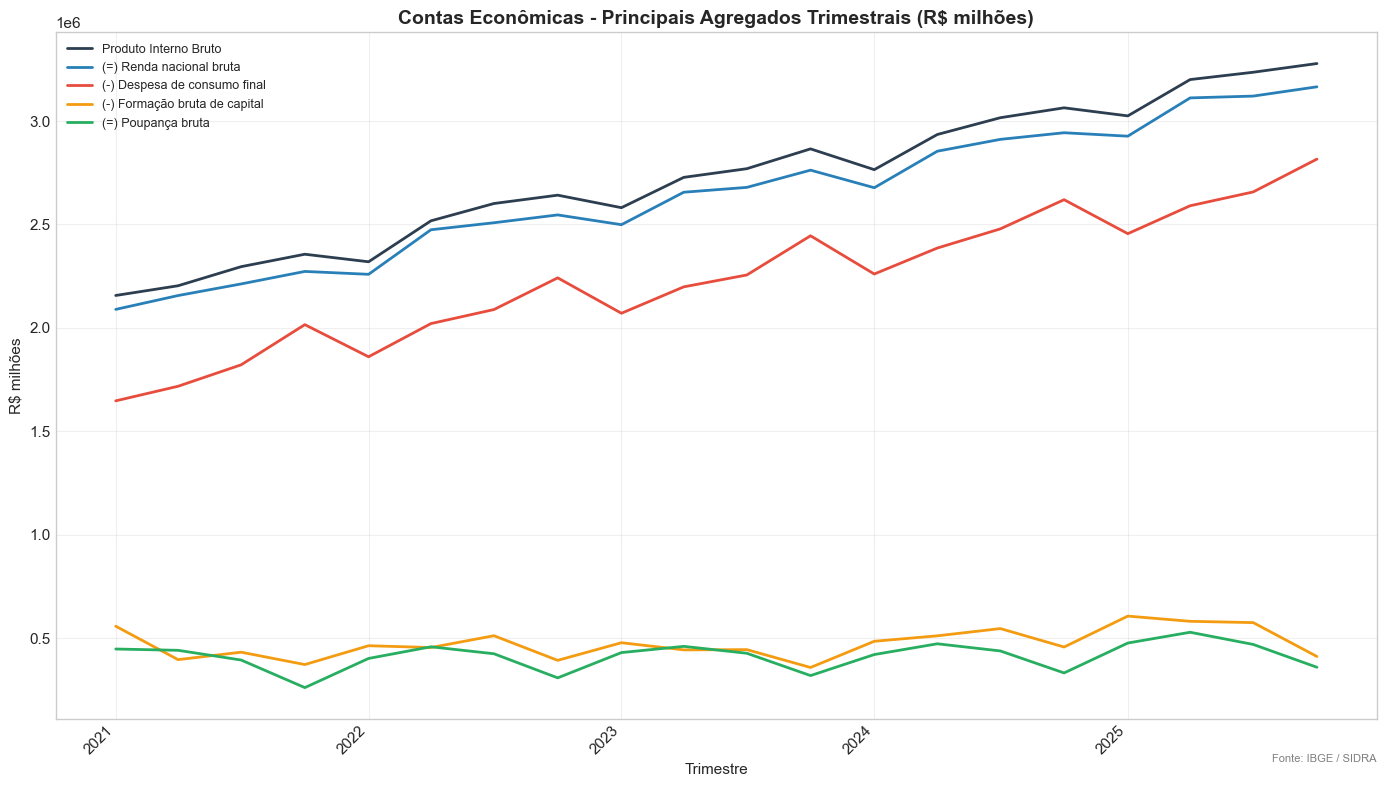

In [14]:
contas_key_cols = [
    'contas_economicas__Produto Interno Bruto',
    'contas_economicas__(=) Renda nacional bruta',
    'contas_economicas__(-) Despesa de consumo final',
    'contas_economicas__(-) Formação bruta de capital',
    'contas_economicas__(=) Poupança bruta',
]

# Filtrar para os que existem
contas_key_cols = [c for c in contas_key_cols if c in q.columns]

fig, ax = plt.subplots(figsize=(14, 8))

colors_contas = ['#2c3e50', '#2980b9', '#e74c3c', '#f39c12', '#27ae60', '#8e44ad']
for i, col in enumerate(contas_key_cols):
    label = col.replace('contas_economicas__', '')
    data = q[col].dropna()
    data = pd.to_numeric(data, errors='coerce').dropna()
    ax.plot(data.index, data.values, linewidth=2, label=label,
            color=colors_contas[i % len(colors_contas)])

ax.set_title('Contas Econômicas - Principais Agregados Trimestrais (R$ milhões)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('R$ milhões')
ax.set_xlabel('Trimestre')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
rotate_labels(ax)
add_source(ax)

plt.tight_layout()
plt.show()

## PIA Mineração - Receita por Setor

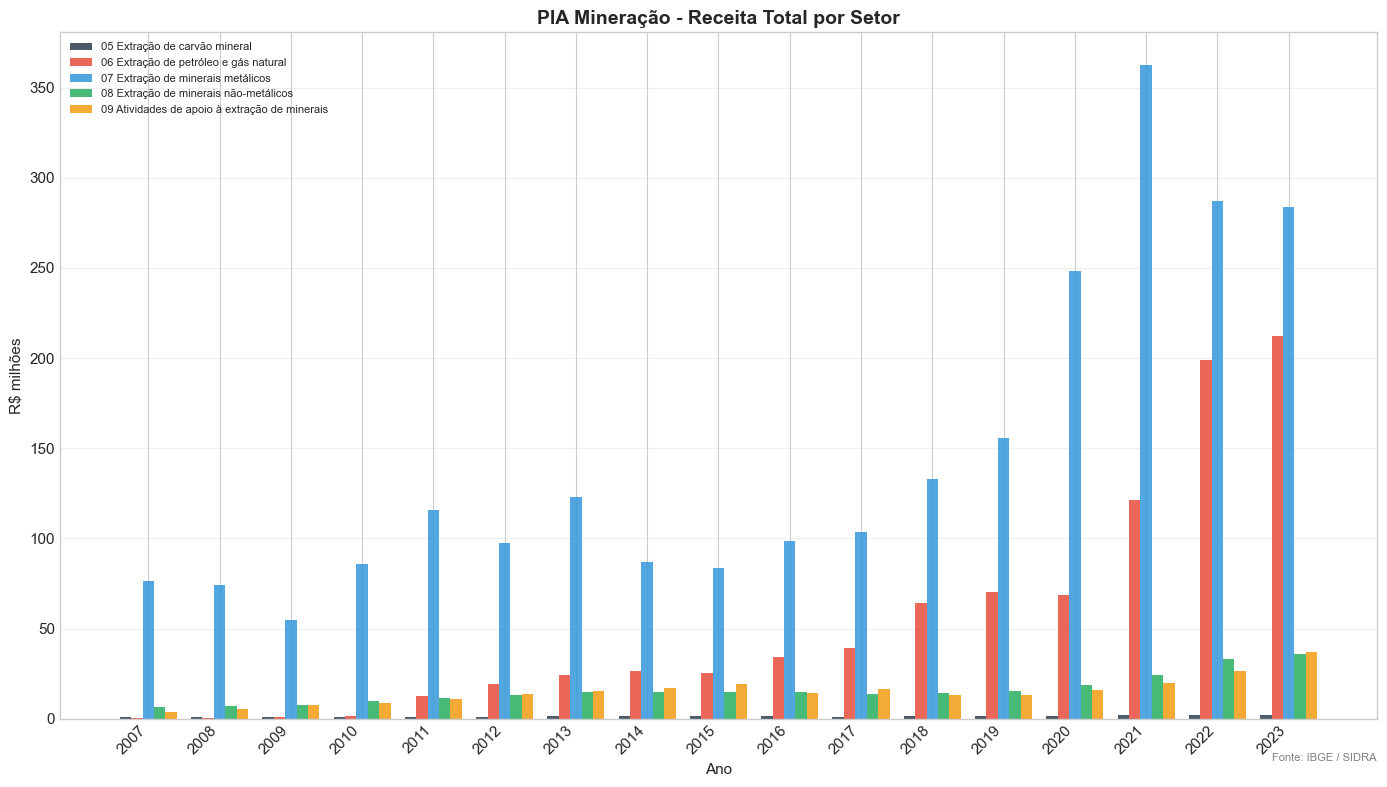

In [15]:
receita_cols = [c for c in a.columns if c.startswith('pia_mineracao__Receita - total')]

fig, ax = plt.subplots(figsize=(14, 8))

df_rec = a[receita_cols].apply(pd.to_numeric, errors='coerce').dropna(how='all')
labels = [c.split(' - ')[-1] for c in receita_cols]

n_years = len(df_rec)
n_sectors = len(receita_cols)
x = np.arange(n_years)
width = 0.8 / n_sectors

colors_pia = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60', '#f39c12']
for i, (col, label) in enumerate(zip(receita_cols, labels)):
    vals = df_rec[col].values / 1e6  # convert to R$ millions
    ax.bar(x + i * width, vals, width, label=label,
           color=colors_pia[i % len(colors_pia)], alpha=0.85)

ax.set_title('PIA Mineração - Receita Total por Setor', fontsize=14, fontweight='bold')
ax.set_ylabel('R$ milhões')
ax.set_xlabel('Ano')
ax.set_xticks(x + width * (n_sectors - 1) / 2)
ax.set_xticklabels([d.strftime('%Y') for d in df_rec.index], rotation=45, ha='right')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
add_source(ax)

plt.tight_layout()
plt.show()

## PAIC Construção - Painel 2x2

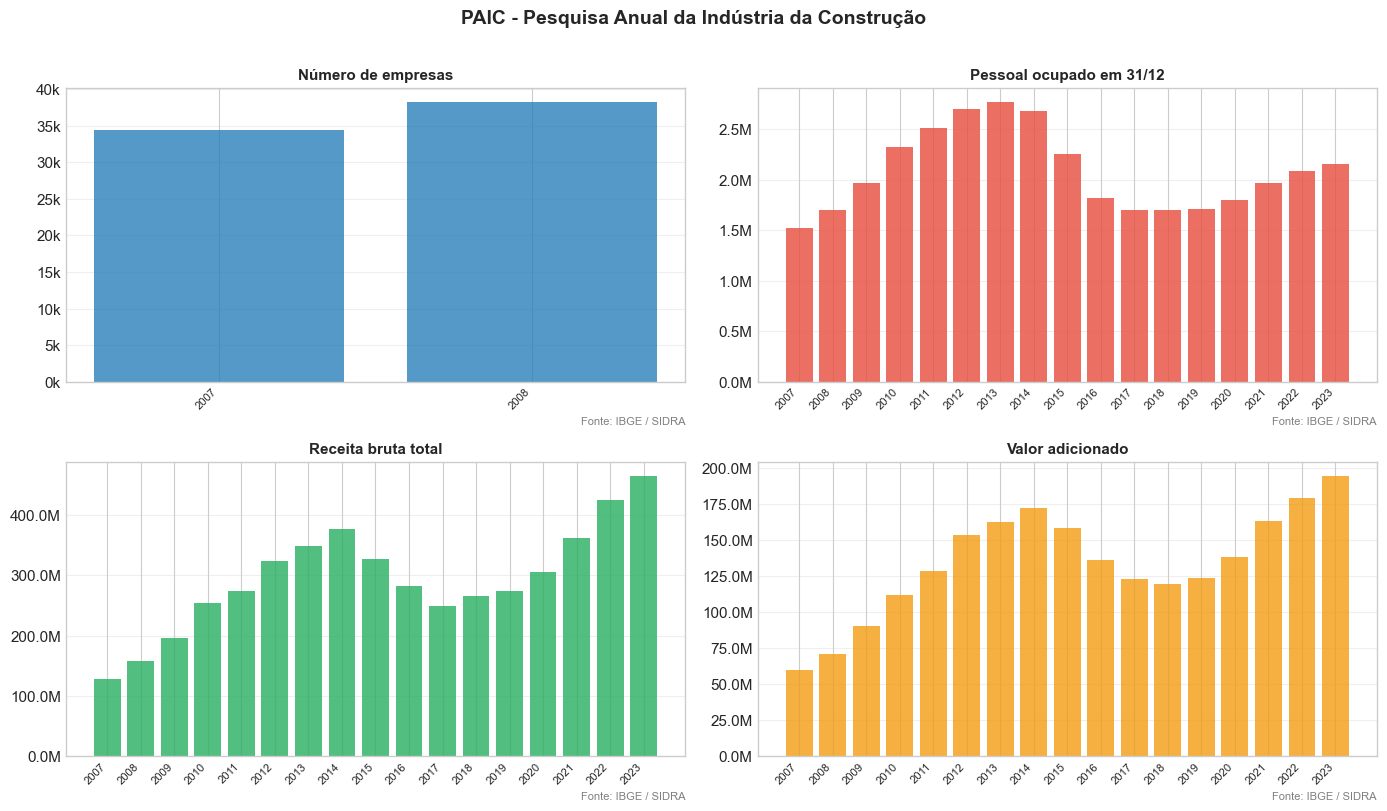

In [16]:
paic_cols = [c for c in a.columns if c.startswith('paic_construcao__')]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

colors_paic = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12']

for i, col in enumerate(paic_cols[:4]):
    ax = axes[i]
    label = col.replace('paic_construcao__', '').replace(' - Total - Total', '')
    data = pd.to_numeric(a[col], errors='coerce').dropna()

    years = [d.strftime('%Y') for d in data.index]

    ax.bar(years, data.values, color=colors_paic[i], alpha=0.8)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

    # Formatar eixo y para números grandes
    if data.max() > 1e6:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    elif data.max() > 1e3:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

    add_source(ax)

fig.suptitle('PAIC - Pesquisa Anual da Indústria da Construção', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()